
# Exploratory Data Analysis - (EDA) Project

##  Client & Context

**Client:** Amy Williams  
**Role:** Property Seller  
**Profile:**
- Sells **luxury, central properties (top 10%)**
- Buys **average houses in outskirts** for strategic reasons

**Objective:**
Maximize profit from high-end property sales while acquiring low-profile properties at optimal prices.

---

##  Project Workflow

1. **Download the dataset (CSV)**
2. **Import the data**
3. **Data cleaning**
4. **Understand the data**
   - Generate hypotheses
   - Define key concepts
5. **Data visualization**
6. **Insights generation**
7. **Presentation of findings**

---

##  Understanding the Data

### Key Definitions

- **Luxury Houses**
  - Top 10% in price distribution
  - Premium features (e.g., waterfront, large area, modern condition)

- **Central vs Outskirts**
  - *Central:* High-value zip codes
  - *Outskirts:* Lower-value zip codes

- **Average Houses**
  - Mid-range pricing (e.g., 40th–60th percentile)
  - Standard features, no luxury premiums

- **Timing**
  - Identify seasonal price trends
  - Detect peak selling and low buying periods


## Data Visualization

- Distribution plots (price)
- Boxplots (price by zipcode)
- Scatterplot
- Time series plots (price over months)

---

## Strategy Definition

### SELL Strategy
Sell properties that:
- Are in the **top 10% price range**
- Located in **high-value zip codes**
- Have **premium features**
- Sold during **peak months**

---

###  BUY Strategy
Buy properties that:
- Are **mid-priced (average houses)**
- Located in **low-value zip codes (outskirts)**
- Have **good fundamentals**
- Purchased during **low-price periods**


In [16]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import psycopg2



In [10]:
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)
cur = conn.cursor()

cur.execute("""
SELECT *
FROM eda.king_county_house_sales kchs
LEFT JOIN eda.king_county_house_details kchd
ON kchs.house_id = kchd.id
""")
rows = cur.fetchall()
columns = [desc[0] for desc in cur.description]

OperationalError: connection to server on socket "/tmp/.s.PGSQL.5432" failed: No such file or directory
	Is the server running locally and accepting connections on that socket?


##  Data Preparation

### Import Data
- Load CSV into pandas DataFrame


In [ ]:

df = pd.read_csv("data/dataset.csv")
#df = pd.DataFrame(rows, columns=columns)
df.describe()


,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,2.159700e+04,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,...,21597.000000,21597.000000,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,5.402966e+05,4.580474e+09,10799.000000,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,...,7.657915,1788.596842,291.857224,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512
std,3.673681e+05,2.876736e+09,6234.661218,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,...,1.173200,827.759761,442.490863,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950
min,7.800000e+04,1.000102e+06,1.000000,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,...,3.000000,370.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.220000e+05,2.123049e+09,5400.000000,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.904930e+09,10799.000000,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,6.450000e+05,7.308900e+09,16198.000000,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,9.900000e+09,21597.000000,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,...,13.000000,9410.000000,4820.000000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#### First look at the dataset

Besides the invalid yr_renovated values, there are a few additional data quality issues worth addressing. Extremely high values in bedrooms (e.g., 33) likely represent errors and should be capped or removed. Some features such as waterfront and sqft_basement contain missing values that can reasonably be imputed as 0. Additionally, duplicate identifier columns (id, id.1) should be removed to avoid confusion. Overall, most variables are usable, but minor cleaning would improve reliability.


In [ ]:
df[df["bedrooms"] > 10][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "zipcode"]
].sort_values("bedrooms", ascending=False).iloc[1:]

df = df[~((df["bedrooms"] == 33) & (df["sqft_living"] == 1620))]


In [ ]:
df[df["bathrooms"] > 7][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "zipcode"]
].sort_values("bedrooms", ascending=False)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,zipcode
8537,450000.0,9.0,7.50,4050.0,6504.0,98144
12764,2280000.0,7.0,8.00,13540.0,307752.0,98053
7245,7700000.0,6.0,8.00,12050.0,27600.0,98102
9245,6890000.0,6.0,7.75,9890.0,31374.0,98039


In [ ]:
df["yr_renovated"].value_counts().sort_index()

yr_renovated
0.0        17004
19340.0        1
19400.0        2
19440.0        1
19450.0        3
           ...  
20110.0        9
20120.0        8
20130.0       31
20140.0       73
20150.0       14
Name: count, Length: 70, dtype: int64

##  Data Cleaning
- Handle missing values  
- Remove duplicates  
- Fix data types  
- Validate consistency  




In [ ]:
columns_needed = [
    'house_id',
    'date',
    'price',
    'zipcode',
    'lat',
    'long',
    'sqft_living',
    'sqft_lot',
    'sqft_basement',
    'bedrooms',
    'bathrooms',
    'floors',
    'grade',
    'condition',
    'waterfront',
    'view'
]

df_subset = df[columns_needed]
df_subset

,house_id,date,price,zipcode,lat,long,sqft_living,sqft_lot,sqft_basement,bedrooms,bathrooms,floors,grade,condition,waterfront,view
0,7129300520,2014-10-13,221900.0,98178,47.5112,-122.257,1180.0,5650.0,0.0,3.0,1.00,1.0,7,3,NaN,0.0
1,6414100192,2014-12-09,538000.0,98125,47.7210,-122.319,2570.0,7242.0,400.0,3.0,2.25,2.0,7,3,0.0,0.0
2,5631500400,2015-02-25,180000.0,98028,47.7379,-122.233,770.0,10000.0,0.0,2.0,1.00,1.0,6,3,0.0,0.0
3,2487200875,2014-12-09,604000.0,98136,47.5208,-122.393,1960.0,5000.0,910.0,4.0,3.00,1.0,7,5,0.0,0.0
4,1954400510,2015-02-18,510000.0,98074,47.6168,-122.045,1680.0,8080.0,0.0,3.0,2.00,1.0,8,3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,2014-05-21,360000.0,98103,47.6993,-122.346,1530.0,1131.0,0.0,3.0,2.50,3.0,8,3,0.0,0.0
21593,6600060120,2015-02-23,400000.0,98146,47.5107,-122.362,2310.0,5813.0,0.0,4.0,2.50,2.0,8,3,0.0,0.0
21594,1523300141,2014-06-23,402101.0,98144,47.5944,-122.299,1020.0,1350.0,0.0,2.0,0.75,2.0,7,3,0.0,0.0
21595,291310100,2015-01-16,400000.0,98027,47.5345,-122.069,1600.0,2388.0,0.0,3.0,2.50,2.0,8,3,NaN,0.0


In [17]:
df_subset.info()

<class 'pandas.DataFrame'>
Index: 21596 entries, 0 to 21596
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21596 non-null  int64         
 1   date           21596 non-null  datetime64[us]
 2   price          21596 non-null  Int64         
 3   zipcode        21596 non-null  int64         
 4   lat            21596 non-null  float64       
 5   long           21596 non-null  float64       
 6   sqft_living    21596 non-null  Int64         
 7   sqft_lot       21596 non-null  Int64         
 8   sqft_basement  21596 non-null  float64       
 9   bedrooms       21596 non-null  Int64         
 10  bathrooms      21596 non-null  float64       
 11  floors         21596 non-null  float64       
 12  grade          21596 non-null  Int64         
 13  condition      21596 non-null  Int64         
 14  waterfront     21596 non-null  Int64         
 15  view           21596 non-null  Int6

In [18]:
# Date cleaning and added new columns around month and year
# filled missing values in view and waterfront with 0

df_subset["date"] = pd.to_datetime(df_subset["date"])
df_subset["year"] = df_subset["date"].dt.year
df_subset["month"] = df_subset["date"].dt.month
df_subset["view"] = df_subset["view"].fillna(0)
df_subset["waterfront"] = df_subset["waterfront"].fillna(0)
df_subset["sqft_basement"] = df_subset["waterfront"].fillna(0)




In [19]:
# Further cleaning convert values to int for readability

cols_to_int = [
    "bedrooms",
    "floors",
    "waterfront",
    "view",
    "grade",
    "condition",
    "sqft_lot",
    "sqft_living",
    "price"
]

for col in cols_to_int:
    if (df_subset[col] % 1 == 0).all():
        df_subset[col] = df_subset[col].astype("Int64")


In [20]:
# For house level analysis (not seasonality) we cleaned the dataset to keep only the last sales 
# record per house. The goal is to identify the luxury houses and what makes them luxurious

df_latest = (
    df_subset.sort_values("date")
      .drop_duplicates(subset="house_id", keep="last")
)

---

### Hypothesis 1
> Houses with premium features (e.g., waterfront, condition, grade) belong to the top 10% price segment.

### Hypothesis 2
> There are specific months where house prices peak (ideal for selling) and dip (ideal for buying).

### Hypothesis 3
> Houses in high-priced zipcodes are more likely to belong to the top 10% price segment.
---

## Luxury Segment (Top 10%)

###  Objective

The objective of this section is to identify what defines luxury properties (top 10% of prices), 
where they are located, and how this segment can be leveraged for strategic buying and selling decisions.

---

### Approach

To better understand this segment, we analyze the key characteristics of luxury properties, focusing on:

- **Size:** `sqft_living`, `sqft_lot`  
- **Structure:** `bedrooms`, `bathrooms`, `floors`  
- **Quality:** `grade`, `condition`  
- **Premium Features:** `waterfront`, `view`  

The goal is to identify what differentiates luxury homes from the rest of the market, both in terms of features and location.

---


In [21]:
price_threshold = df_latest["price"].quantile(0.9)
luxury_df = df_latest[df_latest["price"] >= price_threshold]

min_price = df_latest['price'].min()
max_price = df_latest['price'].max()
mean_price = df_latest['price'].mean()
price_threshold = np.percentile(df_latest['price'], 90)
luxury_df = df_subset[df_subset["price"] >= price_threshold]


print(f"Minimum house price: ${min_price:,.2f}")
print(f"Maximum house price: ${max_price:,.2f}")
print(f"Mean house price: ${mean_price:,.2f}")  

# Calculate the 90th percentile
print(f"Houses priced above ${price_threshold:,.2f} are considered luxury.")

Minimum house price: $78,000.00
Maximum house price: $7,700,000.00
Mean house price: $541,856.85
Houses priced above $889,000.00 are considered luxury.


In [22]:
# How many luxury houses are there?
num_luxury = luxury_df.shape[0]
print(f"There are {num_luxury} luxury houses.")
# Using .shape[0] gives you the number of rows, 
# which corresponds to the number of individual houses in that category.

There are 2153 luxury houses.


In [23]:
# Step 3: Determine "What Counts as Luxury"
# To understand what makes these houses "luxury," 
# you can look at the average (mean) values of their features. 
# This tells you the typical "recipe" for a luxury home in your dataset.

# Calculate mean features for luxury houses
luxury_features = luxury_df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'view']].mean()
print("Average features of a luxury house:")
print(luxury_features)


Average features of a luxury house:
bedrooms           4.019043
bathrooms          3.026939
sqft_living     3568.038551
sqft_lot       23479.593126
grade              9.516024
view               1.011147
dtype: Float64


In [24]:
# To see where these houses are concentrated, group them by their zipcode and count the occurrences. 
# This reveals the "luxury hubs."

# Distribution by Zipcode
location_dist = luxury_df['zipcode'].value_counts()

location_df = luxury_df["zipcode"].value_counts().reset_index()
location_df.columns = ["zipcode", "count"]

# Calculate share and cumulative share
location_df["share"] = location_df["count"] / location_df["count"].sum()
location_df["cum_share"] = location_df["share"].cumsum()

# Keep zipcodes that together make up ~90%
# Include the first zipcode that crosses the 90% boundary

top_90 = location_df[location_df["cum_share"] <= 0.9]
top_90 = location_df.iloc[:len(top_90) + 1].copy()


print(f"Number of zipcodes covering ~90% of luxury houses: {len(top_90)}")
print(top_90[["zipcode", "count", "share", "cum_share"]])

location_df["share"] = location_df["count"] / location_df["count"].sum()
location_df["cum_share"] = location_df["share"].cumsum()

# -----------------------------
# 3. Keep zipcodes that together make up ~90%
#    Include the first zipcode that crosses the 90% boundary
# -----------------------------
top_90 = location_df[location_df["cum_share"] <= 0.9]
top_90 = location_df.iloc[:len(top_90) + 1].copy()

# -----------------------------
# 4. Print summary
# -----------------------------
print(f"Number of zipcodes covering ~90% of luxury houses: {len(top_90)}")
print(top_90[["zipcode", "count", "share", "cum_share"]])


Number of zipcodes covering ~90% of luxury houses: 29
    zipcode  count     share  cum_share
0     98004    223  0.103576   0.103576
1     98040    183  0.084998   0.188574
2     98006    172  0.079889   0.268463
3     98112    140  0.065026   0.333488
4     98033    117  0.054343   0.387831
5     98199     87  0.040409   0.428240
6     98075     79  0.036693   0.464933
7     98105     75  0.034835   0.499768
8     98115     61  0.028333   0.528100
9     98053     60  0.027868   0.555968
10    98074     54  0.025081   0.581050
11    98119     53  0.024617   0.605667
12    98052     49  0.022759   0.628425
13    98005     48  0.022294   0.650720
14    98039     47  0.021830   0.672550
15    98177     44  0.020437   0.692987
16    98144     43  0.019972   0.712959
17    98117     39  0.018114   0.731073
18    98103     38  0.017650   0.748723
19    98027     38  0.017650   0.766373
20    98059     38  0.017650   0.784022
21    98116     38  0.017650   0.801672
22    98109     37  0.0171

/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/4045184330.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


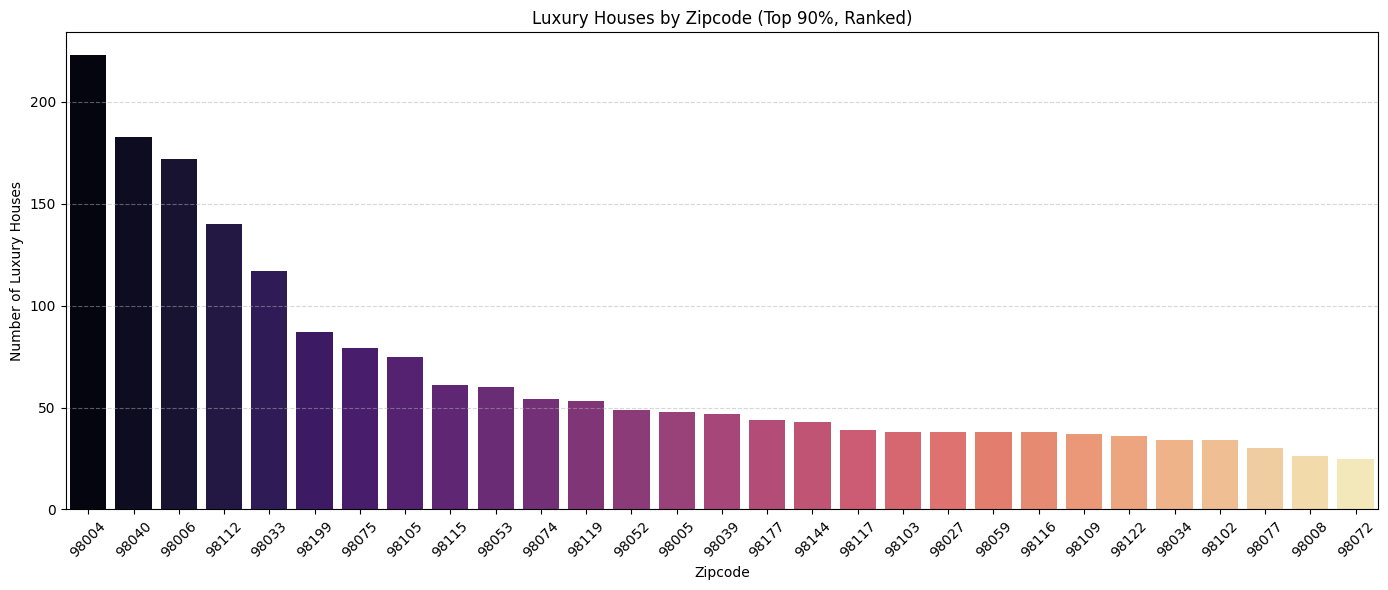

In [25]:
top_90_sorted = top_90.sort_values(by="count", ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_90_sorted,
    x="zipcode",
    y="count",
    palette="magma",
    order=top_90_sorted["zipcode"]  
)

plt.title("Luxury Houses by Zipcode (Top 90%, Ranked)")
plt.xlabel("Zipcode")
plt.ylabel("Number of Luxury Houses")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Insights

- Luxury properties are defined not only by size but by quality (grade) and location.
- The majority of luxury houses are concentrated in a limited number of zipcodes, indicating strong geographic clustering.
- This suggests that location plays a more significant role than individual house features alone in determining luxury pricing.

### Recommendations

- Focus selling efforts on properties located in established luxury zipcodes, where demand and willingness to pay are highest.
- Avoid assuming that large houses automatically qualify as luxury; location must be considered.
- Consider investing in properties near luxury clusters, as these areas may present opportunities for value appreciation.

###  Central vs Outskirts
- Use `zipcode` (primary), `lat/long` (optional)
- Central = **high average price areas**  
- Outskirts = **low average price areas**
- → SELL in central, BUY in outskirts

### Objective

The objective of this section is to identify and compare high-value (“central”) and low-value (“outskirts”) areas based on average house prices, in order to support strategic decision-making.

By classifying locations using price percentiles, we aim to:

Understand how location influences house prices
Quantify the price gap between central and outskirts areas
Identify where to sell high-value properties and where to buy undervalued opportunities

This analysis provides actionable insights to help Amy optimize her investment strategy across different regions.


In [26]:
# Baseline:
# What is the average price per zipcode?
# Which zipcodes are the most expensive?
# Which zipcodes are the cheapest?

zip_price = (
    df_latest.groupby("zipcode")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Average prices for each zipcode: ")
zip_price


Average prices for each zipcode: 


,zipcode,price
0,98039,2187551.020408
1,98004,1355971.761905
2,98040,1194873.638298
3,98112,1096933.929104
4,98102,899607.673077
...,...,...
65,98148,288112.321429
66,98001,282268.849162
67,98032,253317.317073
68,98168,242447.753788


/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/3656304624.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


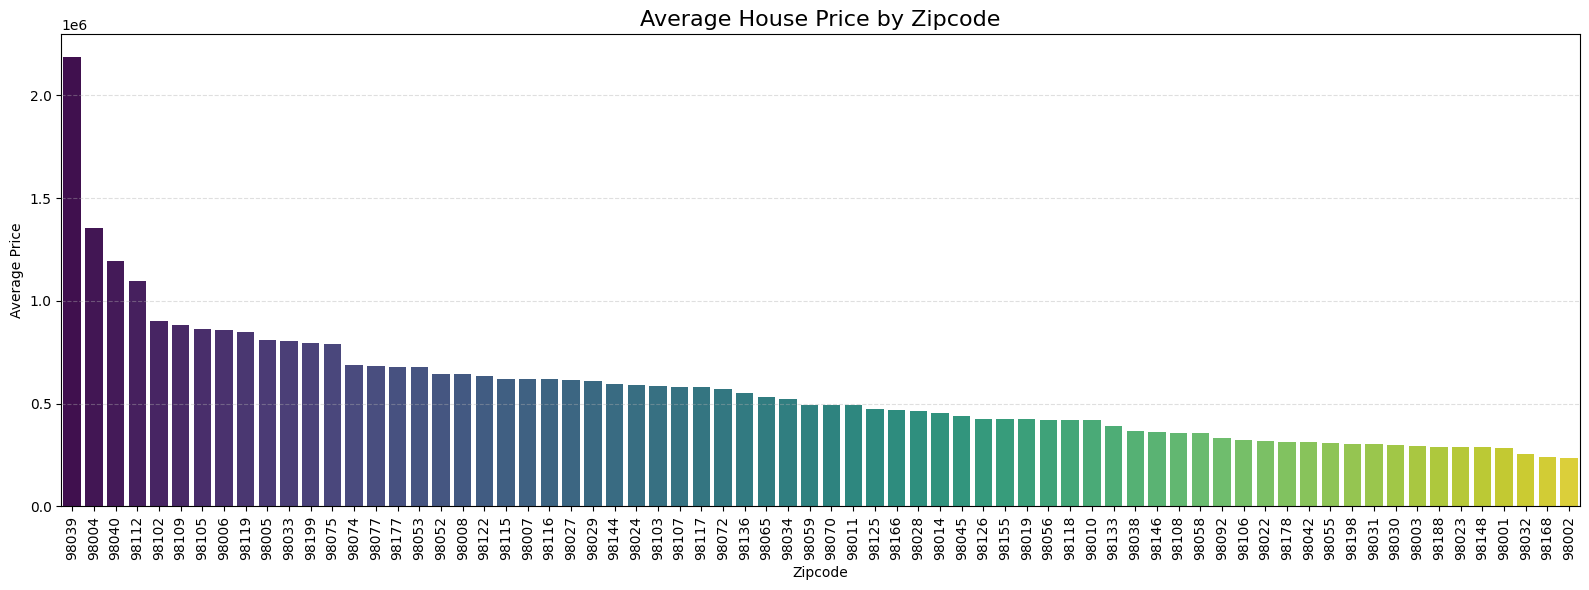

In [ ]:
# Let's plot this filtered data onto a bar chart 
 
plt.figure(figsize=(16, 6))

sns.barplot(
    data=zip_price,
    x="zipcode",
    y="price",
    order=zip_price["zipcode"],
    palette="viridis"
)

plt.title("Average House Price by Zipcode", fontsize=16)
plt.xlabel("Zipcode")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

From this we can make our findings more concise by splitting the chart into 2: Top 10 highest average & Top 10 lowest average

In [ ]:
# Creating the Top10s:

top_10_expensive = zip_price.head(10)
top_10_cheapest = zip_price.tail(10)

print("Top 10 most expensive zipcodes:")
print(top_10_expensive)

print("\nTop 10 cheapest zipcodes:")
print(top_10_cheapest)

Top 10 most expensive zipcodes:
   zipcode           price
0    98039  2187551.020408
1    98004  1355971.761905
2    98040  1194873.638298
3    98112  1096933.929104
4    98102   899607.673077
5    98109   880077.752294
6    98105   863228.943231
7    98006   858149.795918
8    98119   849714.809783
9    98005   810289.696429

Top 10 cheapest zipcodes:
    zipcode          price
60    98031  300970.405904
61    98030  297939.221344
62    98003  295811.894928
63    98188  290034.481481
64    98023  288448.603659
65    98148  288112.321429
66    98001  282268.849162
67    98032  253317.317073
68    98168  242447.753788
69    98002  234606.715736


/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/3591529136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/3591529136.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


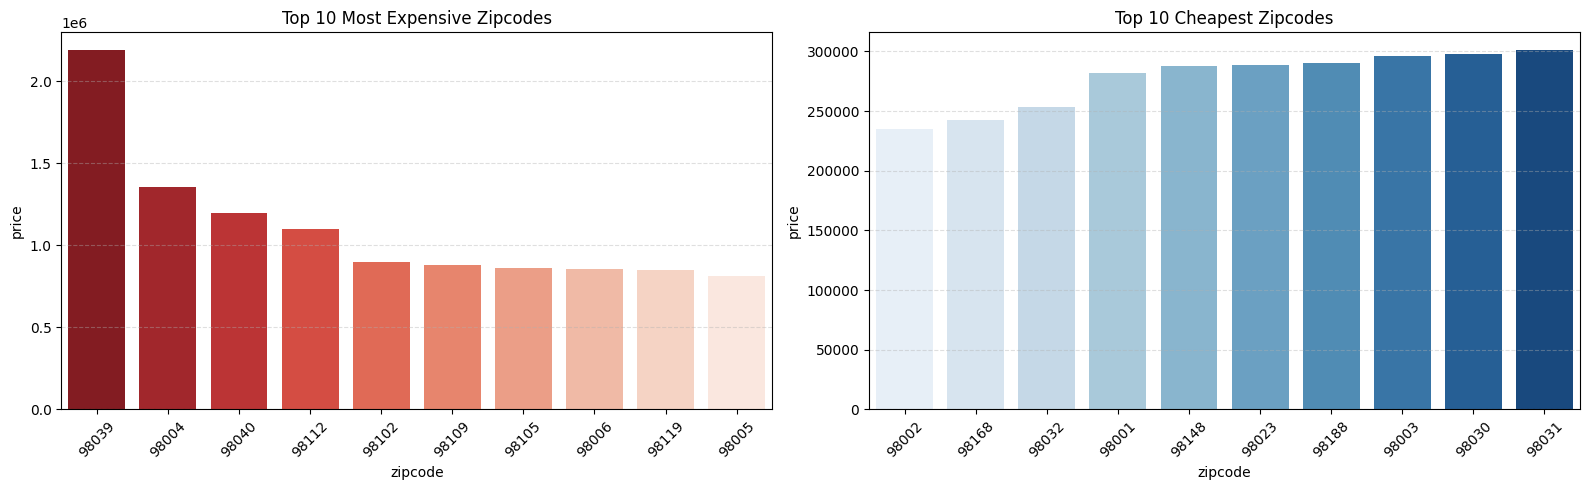

In [ ]:
#Let's plot these onto 2 separate bar charts:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=top_10_expensive,
    x="zipcode",
    y="price",
    order=top_10_expensive["zipcode"],
    palette="Reds_r",
    ax=axes[0]
)
axes[0].set_title("Top 10 Most Expensive Zipcodes")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

sns.barplot(
    data=top_10_cheapest.sort_values("price"),
    x="zipcode",
    y="price",
    order=top_10_cheapest.sort_values("price")["zipcode"],
    palette="Blues",
    ax=axes[1]
)
axes[1].set_title("Top 10 Cheapest Zipcodes")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Hypothesis:
- Zipcodes with average prices above p80 are 'central' and zipcodes with average prices below p40 are 'outskirts' (everything else is middle)

In [ ]:
# Percentiles
p40 = zip_price["price"].quantile(0.4)
p80 = zip_price["price"].quantile(0.8)

# Define zones
central_zips = zip_price.loc[zip_price["price"] >= p80, "zipcode"]
outskirt_zips = zip_price.loc[zip_price["price"] <= p40, "zipcode"]

# Assign
df_latest["area_type"] = "middle"

df_latest.loc[df_latest["zipcode"].isin(central_zips), "area_type"] = "central"
df_latest.loc[df_latest["zipcode"].isin(outskirt_zips), "area_type"] = "outskirts"

print("How many houses are in each category")
df_latest["area_type"].value_counts()

How many houses are in each category


area_type
middle       9031
outskirts    8650
central      3738
Name: count, dtype: int64

In [31]:
central_outskirts_df = df_latest[
    df_latest["area_type"].isin(["central", "outskirts"])
].copy()

avg_price_area = (
    central_outskirts_df.groupby("area_type")["price"]
    .agg(["mean", "median", "min", "max", "count"])
    .reset_index()
)

/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/2163215035.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


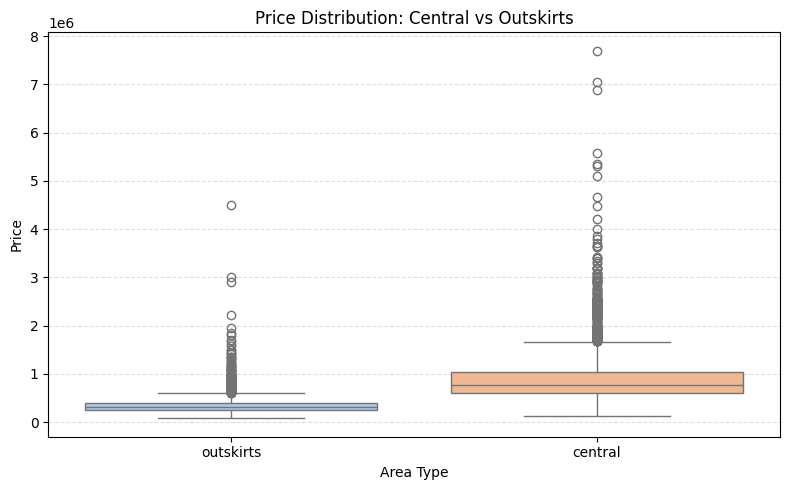

Statistics central vs outskirts:
   area_type           mean    median     min      max  count
0    central  921847.077582  772000.0  130000  7700000   3738
1  outskirts  342492.853064  313100.0   78000  4500000   8650


In [ ]:
# We identified luxurious houses in luxury_df -> We go under the assumption that the luxurious houses are centrally located 
# But do central areas only have high prices, or just higher on average?

## Let's plot this onto a box chart

plt.figure(figsize=(8,5))

sns.boxplot(
    data=central_outskirts_df,
    x="area_type",
    y="price",
    palette="pastel"
)

plt.title("Price Distribution: Central vs Outskirts")
plt.xlabel("Area Type")
plt.ylabel("Price")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


print("Statistics central vs outskirts:")
print(avg_price_area)


In [ ]:
# Despite the visual not being the cleanest, we can show this via a direct comparison:

feature_compare = (
    central_outskirts_df.groupby("area_type")[
        ['price', 'sqft_living','sqft_lot','bedrooms','bathrooms','floors','grade','condition','waterfront','view','sqft_basement']]
    .mean()
    .round(2)
)

print(feature_compare)

               price  sqft_living  sqft_lot  bedrooms  bathrooms  floors  \
area_type                                                                  
central    921847.08      2612.12  11269.61      3.65       2.45    1.59   
outskirts  342492.85      1850.15  15329.61       3.3       1.96    1.39   

           grade  condition  waterfront  view  sqft_basement  
area_type                                                     
central      8.5       3.48        0.01  0.38           0.01  
outskirts   7.25       3.41         0.0  0.16            0.0  


### Central vs Outskirts: What Drives Price Differences?

Comparing average house features across central and outskirts areas reveals a clear pattern:

- **Price shows a significant gap**  
  - Central: ~921k  
  - Outskirts: ~342k  

- **House characteristics differ only moderately**  
  - Bedrooms: 3.65 vs 3.3  
  - Bathrooms: 2.45 vs 1.96  
  - Floors: 1.59 vs 1.39  
  - Condition: nearly identical  
  - Grade: slightly higher in central areas  

- **Notable spatial differences**  
  - Central homes have larger **living space**  
  - Outskirts homes have larger **lot sizes**  

This reflects a typical **urban vs suburban trade-off**:  
central areas offer proximity and convenience, while outskirts offer more space.

Most importantly this suggests that price differences are PRIMARILY driven by location rather than house characteristics.

In [34]:
# Define average houses by overall price band
q40 = df_latest["price"].quantile(0.4)
q60 = df_latest["price"].quantile(0.6)

df_latest["is_average"] = df_latest["price"].between(q40, q60)

# Filter average houses in outskirts
amy_buy_targets = df_latest[
    (df_latest["area_type"] == "outskirts") &
    (df_latest["is_average"])
].copy()

buy_target_summary = amy_buy_targets[
    ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "sqft_basement"]
].describe().round(2)

buy_target_summary

,price,sqft_living,bedrooms,bathrooms,grade,sqft_basement
count,1258.0,1258.0,1258.0,1258.00,1258.0,1258.0
mean,446930.42,2280.97,3.59,2.23,7.73,0.0
std,32774.18,689.95,0.89,0.65,0.92,0.05
min,400000.0,670.0,1.0,0.75,5.0,0.0
25%,420000.0,1772.5,3.0,1.75,7.0,0.0
50%,441500.0,2280.0,4.0,2.50,8.0,0.0
75%,470000.0,2730.0,4.0,2.50,8.0,0.0
max,520000.0,5067.0,11.0,5.00,11.0,1.0


Top zipcodes for average buy targets in outskirts:
zipcode
98133    157
98155    120
98118    113
98038     94
98056     92
98126     92
98058     75
98019     60
98042     57
98092     51
Name: count, dtype: int64


/var/folders/wr/gjw6tvn95kv_g95j_d52zln40000gn/T/ipykernel_71100/2452949554.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


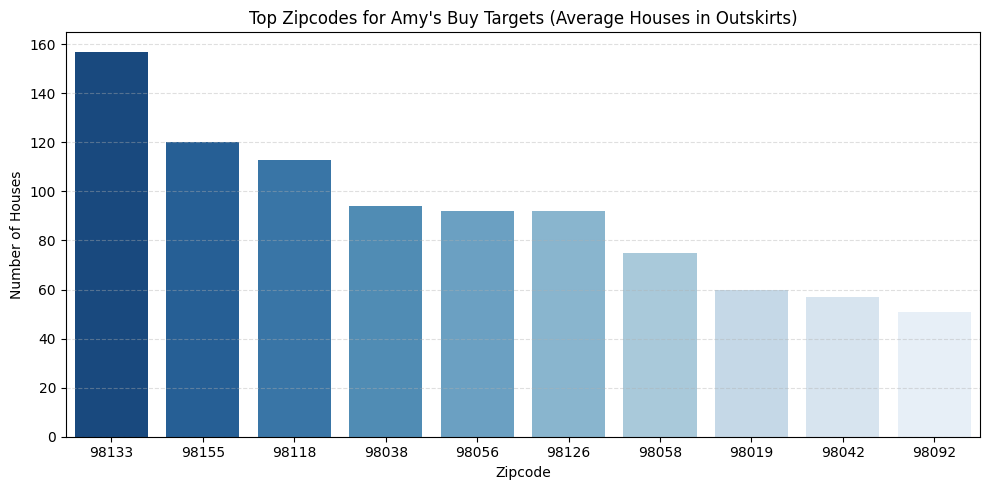

In [ ]:
# Let's find out the top zipcodes in the outskirts based on average price

buy_target_zipcodes = amy_buy_targets["zipcode"].value_counts().head(10)

print("Top zipcodes for average buy targets in outskirts:")
print(buy_target_zipcodes)

plt.figure(figsize=(10,5))

sns.barplot(
    x=buy_target_zipcodes.index.astype(str),
    y=buy_target_zipcodes.values,
    palette="Blues_r"
)

plt.title("Top Zipcodes for Amy's Buy Targets (Average Houses in Outskirts)")
plt.xlabel("Zipcode")
plt.ylabel("Number of Houses")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Now let's finally view all these findings plotted on a map of Kings County
 
df_cop = df_latest.copy()

df_cop["area_type"] = "middle"
df_cop.loc[df_cop["zipcode"].isin(central_zips), "area_type"] = "central"
df_cop.loc[df_cop["zipcode"].isin(outskirt_zips), "area_type"] = "outskirts"

luxury_threshold = df_cop["price"].quantile(0.9)
df_cop["is_luxury"] = df_cop["price"] >= luxury_threshold

q40 = df_cop["price"].quantile(0.4)
q60 = df_cop["price"].quantile(0.6)
df_cop["is_average"] = df_cop["price"].between(q40, q60)

df_cop["is_amy_buy"] = (
    (df_cop["area_type"] == "outskirts") &
    (df_cop["is_average"])
)

df_cop["map_label"] = "Other"

df_cop.loc[df_cop["area_type"] == "outskirts", "map_label"] = "Outskirts"
df_cop.loc[df_cop["area_type"] == "central", "map_label"] = "Central"

df_cop.loc[df_cop["is_amy_buy"], "map_label"] = "Amy Buy Target"
df_cop.loc[
    (df_cop["area_type"] == "central") & (df_cop["is_luxury"]),
    "map_label"
] = "Central Luxury"


map_df = df_cop[df_cop["map_label"] != "Other"].copy()

fig = px.scatter_map(
    map_df,
    lat="lat",
    lon="long",
    color="map_label",
    hover_name="price",
    hover_data={
        "zipcode": True,
        "price": True,
        "area_type": True,
        "is_luxury": True,
        "is_average": True,
        "lat": False,
        "long": False
    },
    color_discrete_map={
    "Central Luxury": "#E63946",   # strong red (SELL)
    "Amy Buy Target": "#2A9D8F",   # strong green/teal (BUY)
    "Central": "#F4A261",          # light orange (warm, expensive area)
    "Outskirts": "#A8DADC"         # light blue (cool, cheaper area)
    },
    zoom=9,
    height=700
)

# Base marker style
fig.update_traces(marker=dict(size=6, opacity=0.5))

# Highlight the important categories
fig.for_each_trace(
    lambda t: t.update(marker=dict(size=9, opacity=0.9))
    if t.name in ["Central Luxury", "Amy Buy Target"] else ()
)

fig.update_layout(
    title="Amy's Strategy Map: Sell vs Buy Opportunities",
    title_x=0.5,
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

### Hypothesis:

- The closer to 'central' you go the higher the prices of the "average" houses goes up.

The first thing from this statement that needs to be taken into consideration is the word "average". After asking Amy this she confirmed that this meant both in terms of price AND in terms of house quality in accordance to real-estate ratings.

In [44]:
# Let's now rearrange the columns in order of importance:

cols2 = ['price', 'grade', 'condition', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'waterfront', 'zipcode', 'lat', 'long', 'date', 'house_id']

# Now let's index 'house_id' and remove the 'house_id' as a column:

df_avg = df_cop.loc[:, cols2].set_index('house_id')

# Let's filter the data:

df_avg = df_avg.query(
    "grade == 7 and condition == 3 and bedrooms == 3 and bathrooms == 2 and floors == 1 and view == 0 and waterfront == 0"
).copy()

## Let's look at the data again

df_avg.describe().round(0)

,price,grade,condition,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,waterfront,zipcode,lat,long,date
count,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259.0,259
mean,349783.0,7.0,3.0,3.0,2.0,1535.0,14668.0,1.0,0.0,0.0,98059.0,48.0,-122.0,2014-10-30 11:23:51.660231
min,158000.0,7.0,3.0,3.0,2.0,930.0,2159.0,1.0,0.0,0.0,98001.0,47.0,-122.0,2014-05-05 00:00:00
25%,253050.0,7.0,3.0,3.0,2.0,1330.0,6472.0,1.0,0.0,0.0,98027.0,47.0,-122.0,2014-07-25 00:00:00
50%,315000.0,7.0,3.0,3.0,2.0,1500.0,8011.0,1.0,0.0,0.0,98042.0,47.0,-122.0,2014-10-21 00:00:00
75%,428500.0,7.0,3.0,3.0,2.0,1680.0,10910.0,1.0,0.0,0.0,98092.0,48.0,-122.0,2015-02-21 00:00:00
max,810000.0,7.0,3.0,3.0,2.0,2800.0,222156.0,1.0,0.0,0.0,98199.0,48.0,-122.0,2015-05-07 00:00:00
std,119205.0,0.0,0.0,0.0,0.0,287.0,30522.0,0.0,0.0,0.0,47.0,0.0,0.0,NaN


With the filtered data above we have a list of all houses that meet the real-estate determination of "average"

From this we can first take a look at how the price of these houses is distributed. By doing this we can find those "average" houses that are "averagely" priced

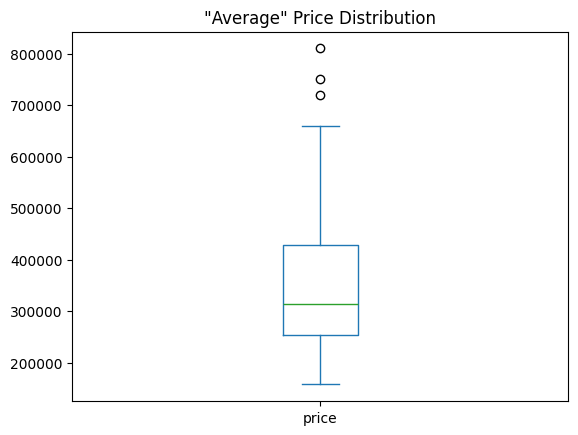

In [45]:
# Let's get an overall view on the "Average" price distribution

df_avg['price'].plot(kind='box', title='"Average" Price Distribution')
plt.show()

From this we can use the interquartile range to establish the price of average-priced, average houses. 

Given that Amy is a mafiosi we can assume money is not an option but rather she is seeking "average" housing to "blend in" and not draw attention. Therefore, this graph illustrates the price range of average housing. I would recommend to Amy to focus on those within the IQR so as to truly have a middle of the road housing.

Now that we have established those houses that fit the "average" criteria, we can move onto locating these on a map to determine if they are in the "outskirts"

We are going to do that by first seeing what the areas of King County are like in terms of the price range and number of "average" houses each zipcode has

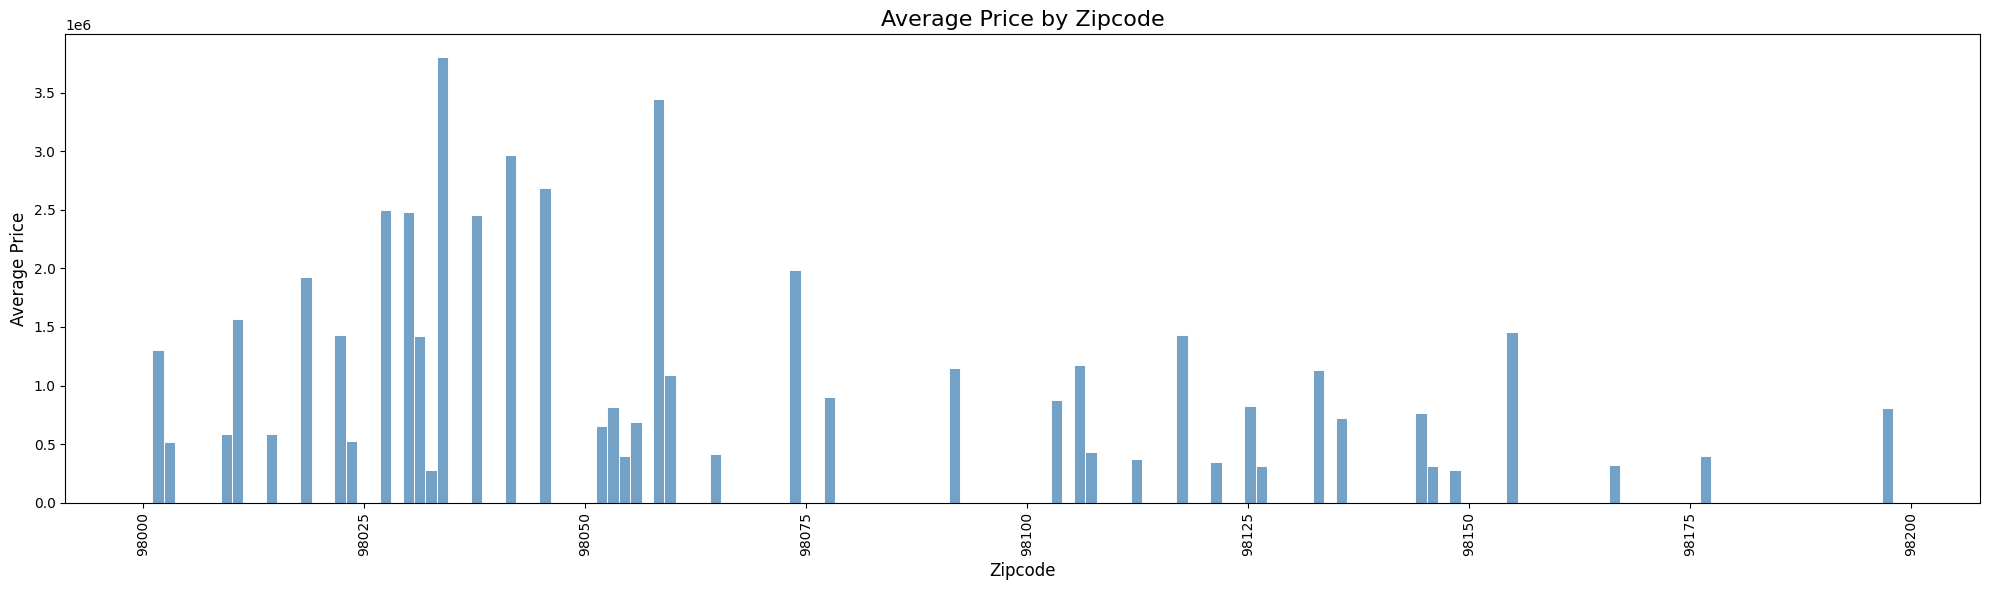

In [47]:
#Filtering the data to only include those properties with an "average" price range (Q1:Q3)

df_avmin = df_avg[(df_avg['price'] <= 450000) & (df_avg['price'] >= 250000)]

df_avmin = df_avmin.sort_values(['price', 'sqft_living', 'sqft_lot'], ascending=False)

# Plotting this dataset onto a histogram to see what areas have the more pricier average properties

plt.figure(figsize=(20, 6))
sns.histplot(
    data=df_avmin.reset_index(),
    x='zipcode',
    weights='price',
    bins=len(df_avmin),
    color='steelblue',
    edgecolor='white'
)
plt.title('Average Price by Zipcode', fontsize=16)
plt.xlabel('Zipcode', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Now, it would be good to see a graph that shows us how many "average" houses they have and how they are split price-wise. To do that we can first plot a bar chart and then a scatter map. This will give us great insight into what areas would be best for Amy.

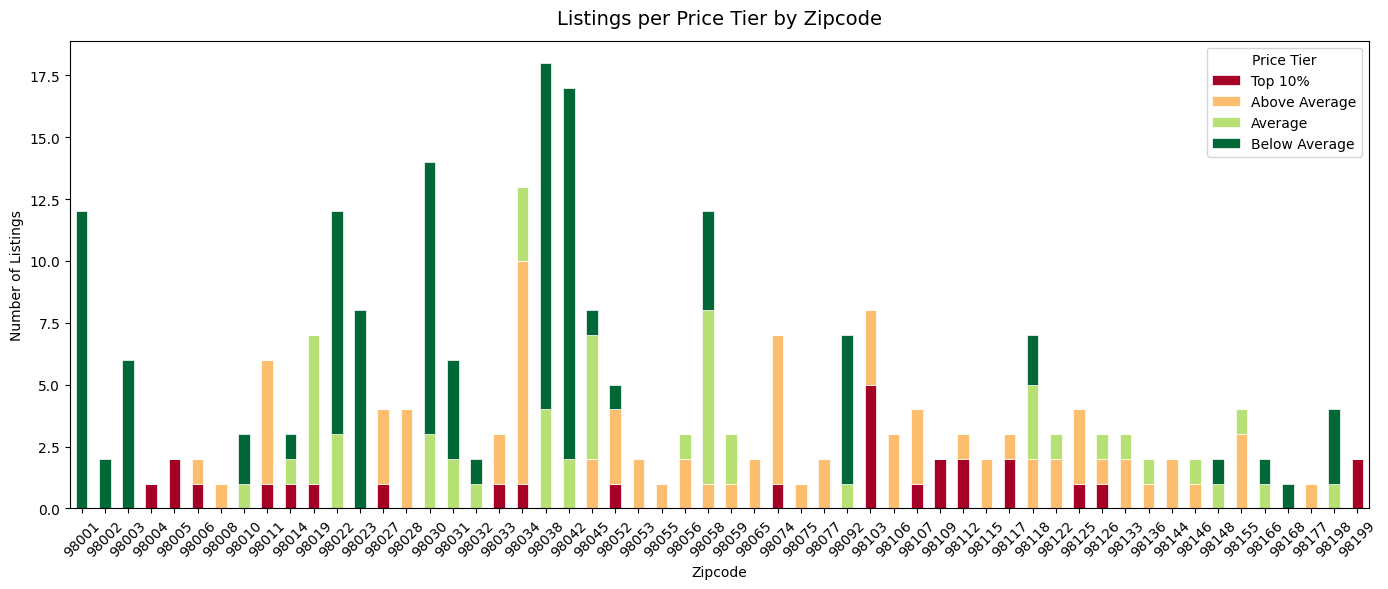

In [48]:
# Visualizing the data as a bar chart. First I need to create the price parameters:

p90 = df_avg['price'].quantile(0.90)
p60 = df_avg['price'].quantile(0.60)
p40 = df_avg['price'].quantile(0.40)

df_t10 = df_avg[df_avg['price'] >= p90]
df_abv = df_avg[(df_avg['price'] <= p90) & (df_avg['price'] >= p60)]
df_mid = df_avg[(df_avg['price'] <= p60) & (df_avg['price'] >= p40)]
df_bel = df_avg[df_avg['price'] <= p40]

# Now to build a new, combined DataFrame with counts per zipcode per tier
tiers = {
    'Top 10%':  df_t10['zipcode'].value_counts(),
    'Above Average': df_abv['zipcode'].value_counts(),
    'Average':       df_mid['zipcode'].value_counts(),
    'Below Average': df_bel['zipcode'].value_counts(),
}


df_tiers = pd.DataFrame(tiers)

# Fill NaN values with 0 (since a missing zip code means 0 occurrences in that tier)
df_tiers = df_tiers.fillna(0).astype(int)

df_pct = df_tiers.div(df_tiers.sum(axis=1), axis=0) * 100

# Now let's visualize this as a bar graph:

dfg = df_tiers.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='RdYlGn',
    edgecolor='white',
    linewidth=0.5,
)

dfg.set_title('Listings per Price Tier by Zipcode', fontsize=14, pad=12)
dfg.set_xlabel('Zipcode')
dfg.set_ylabel('Number of Listings')
dfg.legend(title='Price Tier', loc='upper right')
dfg.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


This graph gives us a better visual insight into what each zipcode offers in terms of average housing.

This can allow Amy to think about what neighbourhood would she prefer to be in when "hiding out". Would it be more beneficial to her to be in an area where there are more houses that are above average, or below?

It would be best for Amy if she can see this on a map for reference. So let's visualize the data as a scatter graph:

In [49]:

# Let's first create a new "price tier" column so we can define our houses into the  4 categories listed above

def assign_color(price):
    if price == 810000:
        return 'Outlier'
    elif price >= p90:
        return 'Top 10%'
    elif p60 <= price <= p90:
        return 'Above Average'
    elif p40 <= price <= p60:
        return 'Average'
    else:
        return 'Below Average'

df_avg['price_tier'] = df_avg['price'].apply(assign_color)

# Let's now plot the graph

map = px.scatter_map(
    df_avg,
    lat="lat",
    lon="long",
    hover_name="price",
    color="price_tier",
    color_discrete_map={
        "Top 10%":               "red",
        "Above Average":         "orange",
        "Average":               "chartreuse",
        "Below Average":         "green",
        "Outlier":               "cyan"
    },
    zoom=9,
    height=500
)

map.update_layout(map_style="open-street-map")
map.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
map.show()


## Insights

- Location is the biggest determiner for the price of a house. Central locality has both higher priced houses as a whole but also has higher "average" house prices
- While living area and other notable characteristics generally correlates with price, the "price-per-square-foot" is not constant across the county.- 
- The "Renovation Ceiling" i.e. there maybe more below average/average houses in the outskirts that are lower priced and thus have an appeal for renovation for profit, it is unlikely to yields much return on investment. This is great for Amy's requirements because this keeps away potential competition.

## Recommendations

Based on all the data above I have selected 6 zipcodes:

1. ### 98038 - Maple Valley
- Top 10 Zipcode?: Yes (#4)
- Number of "Average" houses: 15

2. ### 98058 - Renton
- Top 10 Zipcode?: Yes (#7)
- Number of "Average" houses: 12

3. ### 98042 - Kent
- Top 10 Zipcode?: Yes (#9)
- Number of "Average" houses: 13

4. ### 98045 - North Bend
- Top 10 Zipcode?: No
- Number of "Average" houses: 8

5. ### 98022 - Enumclaw
- Top 10 Zipcode?: No
- Number of "Average" houses: 10


## Selling Over Time (Seasonality Analysis)

- Use `date` → extract month/year
- Identify:
  - **Peak months → SELL**
  - **Low periods → BUY**

#### Objective

Understand how housing market activity varies over time to identify:

    When demand is highest → best time to SELL
    When activity is lowest → best time to BUY

#### Monthly Sales Volume

We first analyze how many houses are sold per month to identify seasonal patterns in market activity.

In [ ]:
monthly_sales = df_subset.groupby("month").size()
top_3_sales = monthly_sales.sort_values(ascending=False).head(3)
bottom_3_sales = monthly_sales.sort_values(ascending=True).head(3)

print(" TOP 3 MONTHS (Overall Sales)")
print(top_3_sales.to_string())

print("\n BOTTOM 3 MONTHS (Overall Sales)")
print(bottom_3_sales.to_string())



In terms of overall sales:

📈 Peak months: May, April, July

📉 Low activity months: January, February, November

#### Luxury vs Overall Market

Next, we compare whether luxury houses follow the same seasonal pattern as the overall market.

In [ ]:
luxury_monthly_sales = luxury_df.groupby("month").size()
top_3_luxury_sales = luxury_monthly_sales.sort_values(ascending=False).head(3)
bottom_3_luxury_sales = luxury_monthly_sales.sort_values(ascending=True).head(3)


print("\n TOP 3 MONTHS (Luxury Sales)")
print(top_3_luxury_sales.to_string())

print("\n BOTTOM 3 MONTHS (Luxury Sales)")
print(bottom_3_luxury_sales.to_string())

Luxury houses peak in April–June

Low activity also in winter months

In [ ]:

combined = pd.DataFrame({
    "month": monthly_sales.index.astype(str),
    "All Houses": monthly_sales.values,
    "Luxury Houses": luxury_monthly_sales.reindex(monthly_sales.index).values
})

combined_melted = combined.melt(
    id_vars="month",
    var_name="Type",
    value_name="Sales"
)

plt.figure(figsize=(10, 5))

# Grouped bars
sns.barplot(
    data=combined_melted,
    x="month",
    y="Sales",
    hue="Type"
)

# Overlay lines using the same x positions / same dataframe
sns.lineplot(
    data=combined,
    x="month",
    y="All Houses",
    marker="o",
    linewidth=2,
    color="blue",
    label="All Houses Trend"
)

sns.lineplot(
    data=combined,
    x="month",
    y="Luxury Houses",
    marker="o",
    linewidth=2,
    color="orange",
    label="Luxury Houses Trend"
)

plt.title("Monthly Sales Volume: Overall vs Luxury Houses")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()


#### Is the luxury share constant over time?

To validate whether seasonality is driven by changes in property types, we calculate the share of luxury houses over time for each month

In [ ]:

luxury_share = (
    luxury_monthly_sales / monthly_sales
)
luxury_share_df = luxury_share.reset_index()
luxury_share_df.columns = ["month", "share"]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=luxury_share_df,
    x="month",
    y="share",
    marker="o",
    linewidth=2.5,
    color="#4C72B0"
)

# Reference line
plt.axhline(
    y=luxury_share_df["share"].mean(),
    color="red",
    linestyle="--",
    label="Average Share"
)

plt.xticks(ticks=range(1, 13), labels=range(1, 13))
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.1f}%")

plt.title("Luxury Share Over Time")
plt.xlabel("Month")
plt.ylabel("Luxury Share (%)")

plt.text(8, luxury_share_df["share"].mean()+0.002,
         "Stable share (~8–11%)",
         color="red")

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

Luxury share remains relatively stable (~8%–11%)

No strong seasonal spikes in luxury proportion

#### Recommendations

Amy should sell her luxury properties in central locations during peak market months (April–June), when both overall and luxury demand are highest, maximizing liquidity and price potential.

Amy should acquire average properties in outskirt areas during winter months (January–February), when market activity is lowest, allowing for more discreet transactions and potentially better negotiation conditions.

Overall, based on the data we have seasonality is driven by transaction volume rather than property type.